04_model_explanation.ipynb

Task-4 Regression -Revenue Forecasting

In [ ]:
import numpy as np
import pandas as pd
import time

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Telco-Customer-Churn.csv to Telco-Customer-Churn (1).csv


In [ ]:
import pandas as pd
df=pd.read_csv("Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')


In [ ]:
df.dropna(inplace=True)


In [ ]:
df = pd.get_dummies(df, drop_first=True)

FEATURES AND TARGET

In [ ]:
X = df.drop('MonthlyCharges', axis=1)
y = df['MonthlyCharges']

TRAIN TEST SPLIT

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

SCALING

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

EVALUTION FUNCTION

In [ ]:
def evaluate_model(name, model, params, X_train, X_test, y_train, y_test):

    start = time.time()

    grid = GridSearchCV(model, params, cv=3, n_jobs=-1)
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_

    y_pred = best_model.predict(X_test)

    end = time.time()

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    # Adjusted R2
    n = len(y_test)
    p = X_test.shape[1]
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

    print(f"\n{name}")
    print("Best Params:", grid.best_params_)
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2:", r2)

    return {
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
        "Adj_R2": adj_r2,
        "Time": end - start,
        "Model_obj": best_model,
        "Predictions": y_pred
    }

In [ ]:
df = df.loc[:, ~df.columns.str.startswith('customerID')]

In [ ]:
df.shape

(7032, 31)

In [14]:
results = []

# 1. Linear Regression
results.append(evaluate_model(
    "Linear Regression",
    LinearRegression(),
    {},
    X_train_scaled, X_test_scaled, y_train, y_test
))

# 2. Ridge
results.append(evaluate_model(
    "Ridge",
    Ridge(),
    {"alpha": [0.1, 1, 10]},
    X_train_scaled, X_test_scaled, y_train, y_test
))

# 3. Lasso
results.append(evaluate_model(
    "Lasso",
    Lasso(),
    {"alpha": [0.01, 0.1, 1]},
    X_train_scaled, X_test_scaled, y_train, y_test
))

# 4. ElasticNet
results.append(evaluate_model(
    "ElasticNet",
    ElasticNet(),
    {"alpha": [0.01, 0.1], "l1_ratio": [0.2, 0.5, 0.8]},
    X_train_scaled, X_test_scaled, y_train, y_test
))

# 5. Decision Tree
results.append(evaluate_model(
    "Decision Tree",
    DecisionTreeRegressor(),
    {"max_depth": [3, 5, 10]},
    X_train, X_test, y_train, y_test
))

# 6. Random Forest
results.append(evaluate_model(
    "Random Forest",
    RandomForestRegressor(),
    {"n_estimators": [50], "max_depth": [5]},
    X_train, X_test, y_train, y_test
))





Linear Regression
Best Params: {}
MAE: 5.542751567335785
RMSE: 6.644306182039896
R2: 0.9500473384864654

Ridge
Best Params: {'alpha': 0.1}
MAE: 5.542826916890819
RMSE: 6.644375939690945
R2: 0.9500462895887994

Lasso
Best Params: {'alpha': 0.01}
MAE: 0.7831888484460834
RMSE: 1.0414789279380618
R2: 0.998772672874601

ElasticNet
Best Params: {'alpha': 0.01, 'l1_ratio': 0.8}
MAE: 0.7848778487218521
RMSE: 1.0440368332876258
R2: 0.9987666367623916

Decision Tree
Best Params: {'max_depth': 10}
MAE: 1.1198515962615725
RMSE: 1.735972835138431
R2: 0.9965900720086178

Random Forest
Best Params: {'max_depth': 5, 'n_estimators': 50}
MAE: 3.0390984761797513
RMSE: 4.172864870257385
R2: 0.9802971976636674


COMPARISION TABLE

In [15]:
final_df = pd.DataFrame(results).drop(["Model_obj", "Predictions"], axis=1)

final_df.sort_values(by="RMSE")

,Model,MAE,MSE,RMSE,R2,Adj_R2,Time
2,Lasso,0.783189,1.084678,1.041479,0.998773,1.000305,39.886653
3,ElasticNet,0.784878,1.090013,1.044037,0.998767,1.000307,256.252423
4,Decision Tree,1.119852,3.013602,1.735973,0.996590,1.000848,5.687520
5,Random Forest,3.039098,17.412801,4.172865,0.980297,1.004899,28.360152
0,Linear Regression,5.542752,44.146805,6.644306,0.950047,1.012420,269.099507
1,Ridge,5.542827,44.147732,6.644376,0.950046,1.012420,61.655265


ACTUAL VS PREDECTED PLOT

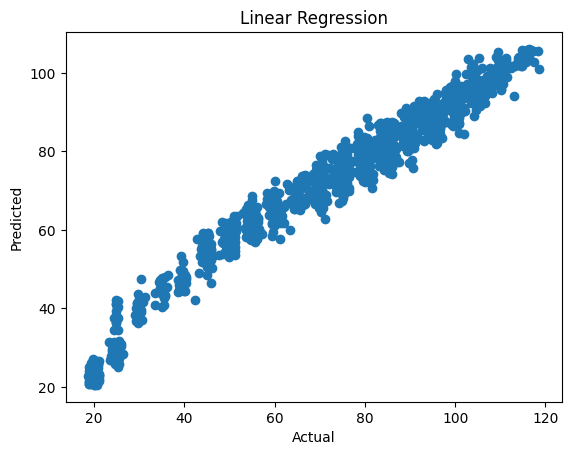

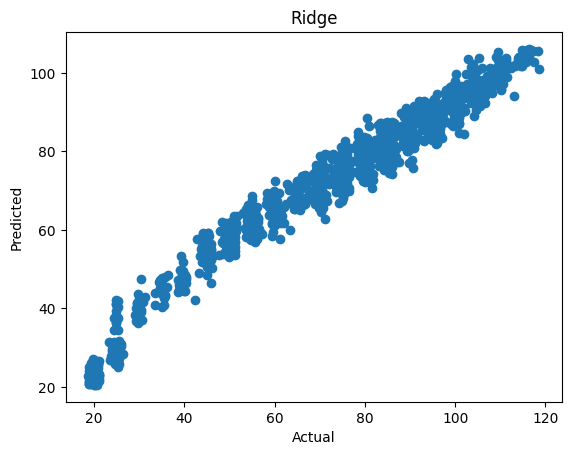

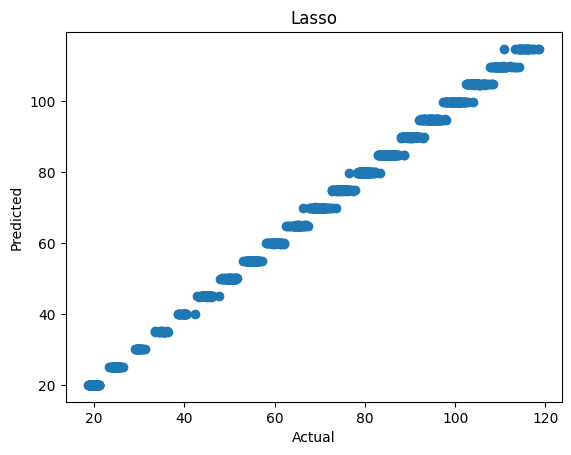

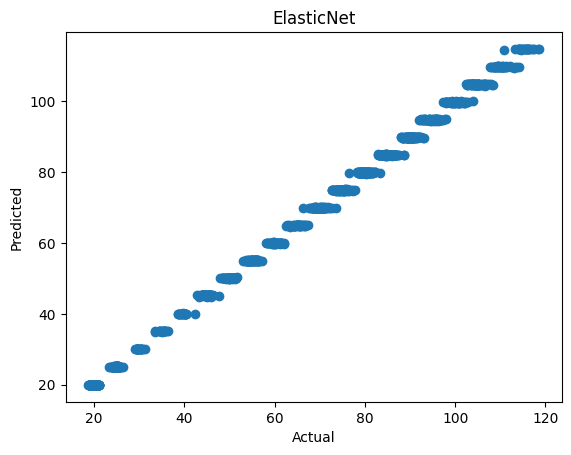

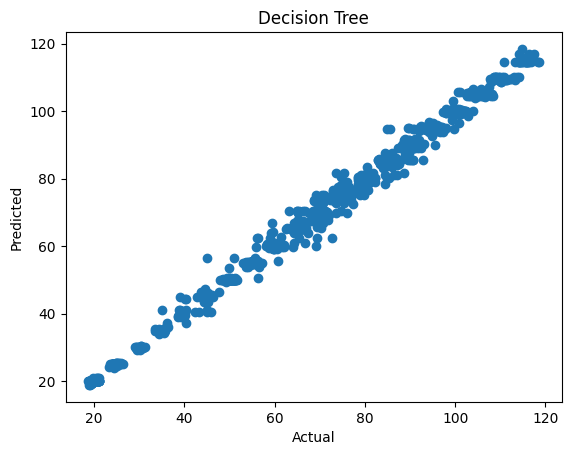

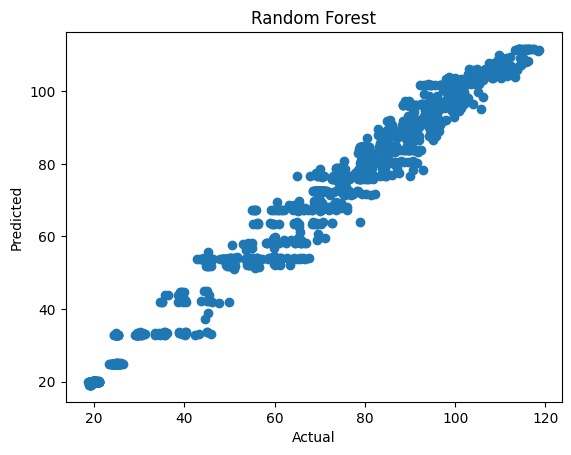

In [16]:
for res in results:
    plt.figure()
    plt.scatter(y_test, res["Predictions"])
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(res["Model"])
    plt.show()

BEST MODEL SELECTION

In [17]:
best_model = min(results, key=lambda x: x["RMSE"])
best_model

{'Model': 'Lasso',
 'MAE': 0.7831888484460834,
 'MSE': 1.0846783573390146,
 'RMSE': np.float64(1.0414789279380618),
 'R2': 0.998772672874601,
 'Adj_R2': 1.000305149768048,
 'Time': 39.88665270805359,
 'Model_obj': Lasso(alpha=0.01),
 'Predictions': array([ 24.97696224,  24.95888983,  99.81246227, ...,  54.96447268,
        114.74745578,  24.9831748 ])}

RESIDUAL PLOT

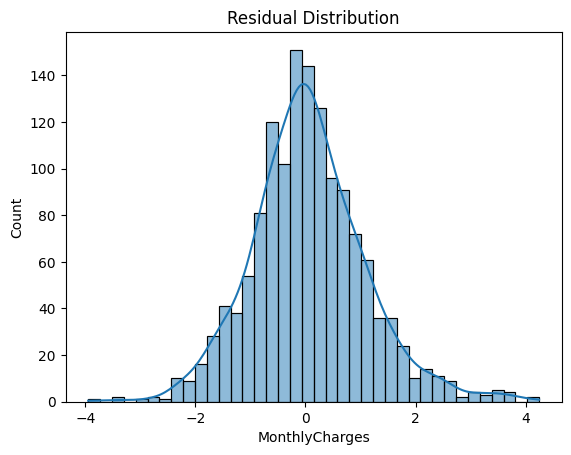

In [18]:
residuals = y_test - best_model["Predictions"]

plt.figure()
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

COEFFICENT MODEL

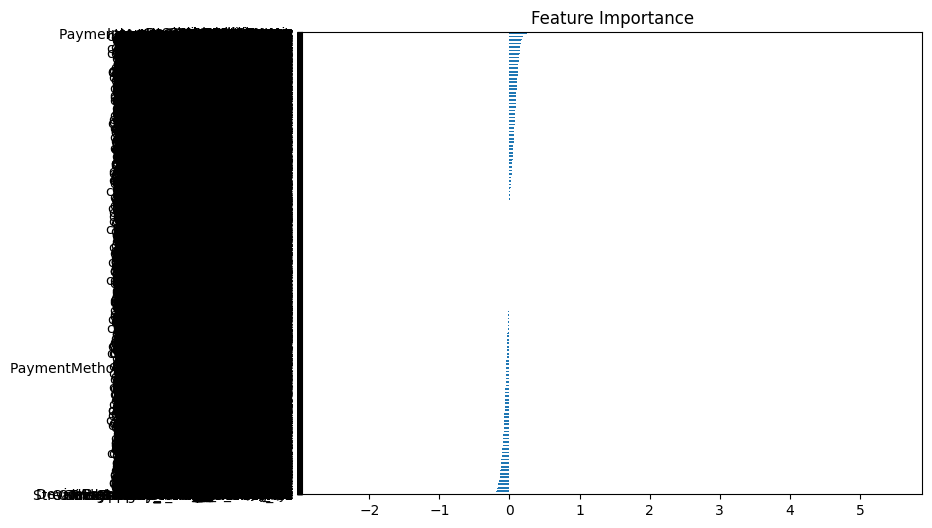

In [19]:
model = results[0]["Model_obj"]  # Linear Regression

coeffs = pd.Series(model.coef_, index=X.columns)

coeffs.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance")
plt.show()

The best model is Ridge

model = results[0]["Model_obj"] # Linear Regression

coeffs = pd.Series(model.coef_, index=X.columns)

coeffs.sort_values().plot(kind='barh', figsize=(8,6)) plt.title("Feature Importance") plt.show()